# Advanced Seaborn Notes

This notebook is a focused study file for the **Seaborn** Python visualization library. It includes proper markdown notes and commented code examples for statistical plotting, categorical analysis, relationships, distributions, grids, styling, and dashboard-style visual summaries.

## Learning Goals

- Understand why Seaborn is useful on top of Matplotlib.
- Create distribution, categorical, relational, regression, heatmap, and grid plots.
- Use `hue`, `style`, `size`, `col`, and `row` to encode extra variables.
- Customize themes, palettes, labels, legends, and figure-level layouts.
- Build clean, readable statistical visualizations for data analysis.

> Note: Seaborn works best with tidy data, where each variable is a column and each observation is a row.

## 1. Import and Setup

The standard alias for Seaborn is `sns`.

Seaborn is built on top of Matplotlib, so we usually import `matplotlib.pyplot` as `plt` for final layout control.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set a clean global theme for all Seaborn plots in this notebook.
sns.set_theme(style="whitegrid", palette="deep", context="notebook")

# Matplotlib still controls some final display properties.
plt.rcParams["figure.figsize"] = (8, 4.5)

sns.__version__

'0.13.2'

## 2. Sample Dataset

To keep this notebook offline-friendly, we create a small local business dataset instead of downloading Seaborn sample datasets.

The dataset is in tidy format: every row is one observation and every column is one variable.

In [3]:
sales = pd.DataFrame({
    "month": ["Jan", "Jan", "Jan", "Feb", "Feb", "Feb", "Mar", "Mar", "Mar", "Apr", "Apr", "Apr"],
    "region": ["North", "South", "West"] * 4,
    "channel": ["Online", "Retail", "Online", "Retail", "Online", "Retail", "Online", "Retail", "Online", "Retail", "Online", "Retail"],
    "revenue": [12000, 9800, 10500, 14500, 13200, 11800, 16000, 14200, 12500, 18500, 15800, 15000],
    "profit": [3200, 2100, 2500, 3900, 3500, 2700, 4300, 3700, 2900, 5100, 4200, 3800],
    "orders": [120, 90, 100, 138, 125, 112, 150, 136, 118, 170, 148, 140],
    "customer_rating": [4.2, 3.9, 4.0, 4.3, 4.1, 4.0, 4.5, 4.2, 4.1, 4.6, 4.3, 4.2]
})

# Add useful derived columns for later examples.
sales["profit_margin"] = (sales["profit"] / sales["revenue"] * 100).round(2)
sales["avg_order_value"] = (sales["revenue"] / sales["orders"]).round(2)

sales

,month,region,channel,revenue,profit,orders,customer_rating,profit_margin,avg_order_value
0,Jan,North,Online,12000,3200,120,4.2,26.67,100.00
1,Jan,South,Retail,9800,2100,90,3.9,21.43,108.89
2,Jan,West,Online,10500,2500,100,4.0,23.81,105.00
3,Feb,North,Retail,14500,3900,138,4.3,26.90,105.07
4,Feb,South,Online,13200,3500,125,4.1,26.52,105.60
5,Feb,West,Retail,11800,2700,112,4.0,22.88,105.36
6,Mar,North,Online,16000,4300,150,4.5,26.88,106.67
7,Mar,South,Retail,14200,3700,136,4.2,26.06,104.41
8,Mar,West,Online,12500,2900,118,4.1,23.20,105.93
9,Apr,North,Retail,18500,5100,170,4.6,27.57,108.82


## 3. Seaborn vs Matplotlib

Matplotlib gives low-level control. Seaborn gives high-level statistical plots with better defaults.

Seaborn usually expects a DataFrame and column names:

```python
sns.lineplot(data=df, x="column_x", y="column_y")
```

This makes plots more readable and easier to modify.

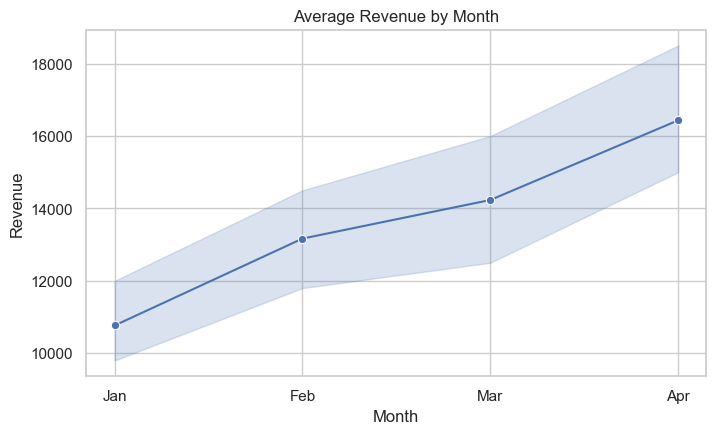

In [4]:
ax = sns.lineplot(data=sales, x="month", y="revenue", marker="o")

# Matplotlib methods can polish Seaborn plots.
ax.set_title("Average Revenue by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")

plt.show()

## 4. Line Plot

`lineplot()` is useful for trends over ordered categories or time.

Use `hue` to split the line by a category.

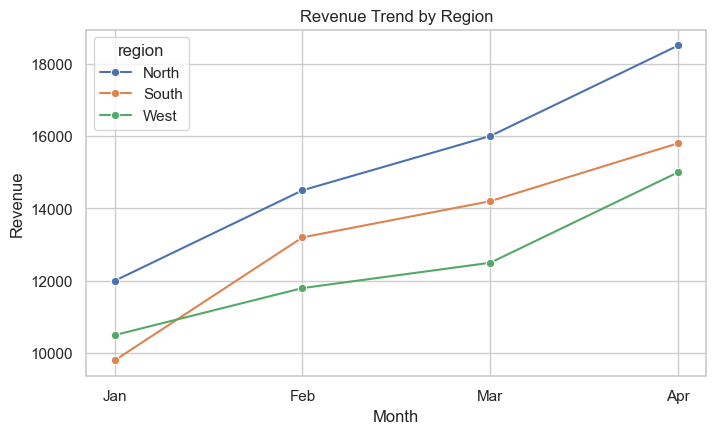

In [5]:
ax = sns.lineplot(
    data=sales,
    x="month",
    y="revenue",
    hue="region",
    marker="o"
)

ax.set_title("Revenue Trend by Region")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")

plt.show()

## 5. Scatter Plot

`scatterplot()` shows relationships between numeric variables.

Useful semantic mappings:

- `hue`: color by category or numeric value.
- `style`: marker style by category.
- `size`: point size by numeric variable.

In [ ]:
ax = sns.scatterplot(
    data=sales,
    x="orders",
    y="revenue",
    hue="region",
    style="channel",
    size="profit_margin",
    sizes=(80, 220)
)

ax.set_title("Orders vs Revenue")
ax.set_xlabel("Orders")
ax.set_ylabel("Revenue")

plt.show()

## 6. Relational Plot

`relplot()` is a figure-level function for relational plots.

It can create multiple subplots using `col` and `row`, which is useful for comparing groups.

In [ ]:
grid = sns.relplot(
    data=sales,
    x="orders",
    y="revenue",
    hue="region",
    col="channel",
    kind="scatter",
    height=4,
    aspect=1
)

grid.fig.suptitle("Orders vs Revenue by Channel", y=1.05)

plt.show()

## 7. Bar Plot

`barplot()` estimates a numeric value for each category.

By default, Seaborn shows an estimator such as the mean. You can use `estimator="sum"` when total values matter.

In [ ]:
ax = sns.barplot(
    data=sales,
    x="region",
    y="revenue",
    hue="channel",
    estimator="sum",
    errorbar=None
)

ax.set_title("Total Revenue by Region and Channel")
ax.set_xlabel("Region")
ax.set_ylabel("Total Revenue")

plt.show()

## 8. Count Plot

`countplot()` counts observations in each category.

It is useful for checking class balance or category frequency.

In [ ]:
ax = sns.countplot(data=sales, x="region", hue="channel")

ax.set_title("Number of Records by Region and Channel")
ax.set_xlabel("Region")
ax.set_ylabel("Record Count")

plt.show()

## 9. Box Plot

`boxplot()` summarizes distribution using median, quartiles, and outliers.

It is useful for comparing spread between groups.

In [ ]:
ax = sns.boxplot(data=sales, x="region", y="profit_margin", hue="channel")

ax.set_title("Profit Margin Distribution by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Profit Margin %")

plt.show()

## 10. Violin Plot

`violinplot()` shows distribution shape and density.

It is more expressive than a box plot, but can be harder to read for small datasets.

In [ ]:
ax = sns.violinplot(data=sales, x="channel", y="avg_order_value", inner="quartile")

ax.set_title("Average Order Value Distribution by Channel")
ax.set_xlabel("Channel")
ax.set_ylabel("Average Order Value")

plt.show()

## 11. Strip Plot and Swarm Plot

`stripplot()` and `swarmplot()` show individual observations.

They are useful when you want to see the actual data points instead of only a summary.

In [ ]:
ax = sns.swarmplot(data=sales, x="region", y="customer_rating", hue="channel", size=7)

ax.set_title("Customer Ratings by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Customer Rating")

plt.show()

## 12. Histogram

`histplot()` shows the distribution of a numeric column.

Use `kde=True` to overlay a smooth density curve.

In [ ]:
ax = sns.histplot(data=sales, x="revenue", bins=6, kde=True, color="#4c78a8")

ax.set_title("Revenue Distribution")
ax.set_xlabel("Revenue")
ax.set_ylabel("Frequency")

plt.show()

## 13. KDE Plot

`kdeplot()` estimates a smooth distribution.

KDE plots are good for comparing distribution shapes, but they are estimates rather than raw counts.

In [ ]:
ax = sns.kdeplot(data=sales, x="profit_margin", hue="channel", fill=True, alpha=0.35)

ax.set_title("Profit Margin Density by Channel")
ax.set_xlabel("Profit Margin %")

plt.show()

## 14. ECDF Plot

`ecdfplot()` shows the empirical cumulative distribution.

It answers questions like: what share of observations are below a value?

In [ ]:
ax = sns.ecdfplot(data=sales, x="revenue", hue="channel")

ax.set_title("Cumulative Distribution of Revenue")
ax.set_xlabel("Revenue")
ax.set_ylabel("Cumulative Probability")

plt.show()

## 15. Regression Plot

`regplot()` adds a regression line to a scatter plot.

It is useful for visually checking whether two numeric variables have a linear relationship.

In [ ]:
ax = sns.regplot(
    data=sales,
    x="orders",
    y="revenue",
    scatter_kws={"s": 80, "alpha": 0.8},
    line_kws={"color": "red"}
)

ax.set_title("Regression: Orders vs Revenue")
ax.set_xlabel("Orders")
ax.set_ylabel("Revenue")

plt.show()

## 16. LM Plot

`lmplot()` is a figure-level regression function.

It supports faceting with `col`, `row`, and grouping with `hue`.

In [ ]:
grid = sns.lmplot(
    data=sales,
    x="orders",
    y="revenue",
    hue="region",
    col="channel",
    height=4,
    aspect=1,
    scatter_kws={"s": 70}
)

grid.fig.suptitle("Regression by Channel", y=1.05)

plt.show()

## 17. Heatmap

`heatmap()` visualizes a matrix using color intensity.

Common use cases include correlation matrices, pivot tables, and confusion matrices.

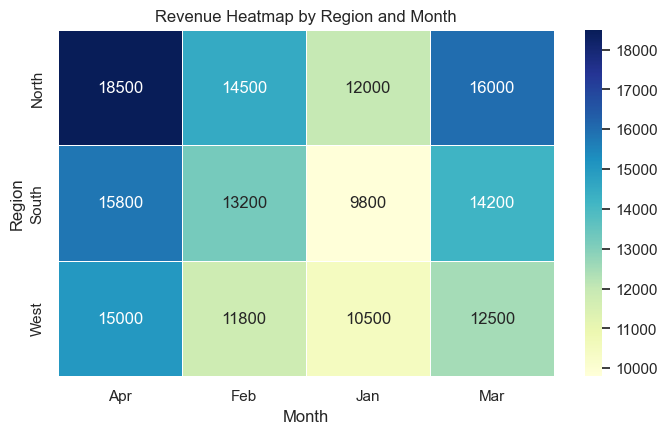

In [6]:
# Create a region by month revenue matrix.
revenue_matrix = sales.pivot_table(
    index="region",
    columns="month",
    values="revenue",
    aggfunc="sum"
)

ax = sns.heatmap(revenue_matrix, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)

ax.set_title("Revenue Heatmap by Region and Month")
ax.set_xlabel("Month")
ax.set_ylabel("Region")

plt.show()

## 18. Correlation Heatmap

A correlation heatmap summarizes linear relationships between numeric columns.

Values near `1` mean strong positive correlation. Values near `-1` mean strong negative correlation.

In [ ]:
numeric_columns = ["revenue", "profit", "orders", "customer_rating", "profit_margin", "avg_order_value"]
corr = sales[numeric_columns].corr()

ax = sns.heatmap(corr, annot=True, cmap="vlag", center=0, fmt=".2f")

ax.set_title("Correlation Heatmap")

plt.show()

## 19. Pair Plot

`pairplot()` creates pairwise plots for numeric variables.

It is useful for quick exploratory data analysis, especially before modeling.

In [ ]:
grid = sns.pairplot(
    sales,
    vars=["revenue", "profit", "orders", "customer_rating"],
    hue="channel",
    corner=True,
    height=2.2
)

grid.fig.suptitle("Pairwise Relationships", y=1.03)

plt.show()

## 20. Joint Plot

`jointplot()` combines a main relationship plot with marginal distributions.

It is useful when you want to see both relationship and distribution in one figure.

In [ ]:
grid = sns.jointplot(data=sales, x="orders", y="revenue", hue="channel", height=6)

grid.fig.suptitle("Orders and Revenue with Marginal Distributions", y=1.03)

plt.show()

## 21. Cat Plot

`catplot()` is a figure-level function for categorical plots.

It supports different `kind` values, including `bar`, `box`, `violin`, `strip`, `swarm`, and `point`.

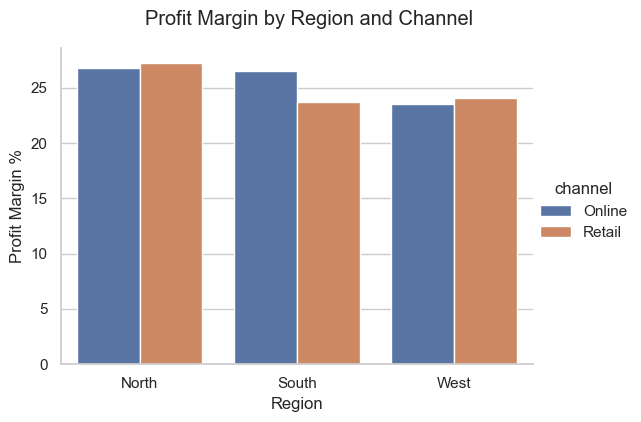

In [7]:
grid = sns.catplot(
    data=sales,
    x="region",
    y="profit_margin",
    hue="channel",
    kind="bar",
    errorbar=None,
    height=4,
    aspect=1.4
)

grid.fig.suptitle("Profit Margin by Region and Channel", y=1.05)
grid.set_axis_labels("Region", "Profit Margin %")

plt.show()

## 22. Facet Grid

`FacetGrid` gives manual control over small multiples.

Use it when you want to apply the same plot across multiple subsets of data.

In [ ]:
grid = sns.FacetGrid(sales, col="region", hue="channel", height=3.5, aspect=1)

# Map a plotting function onto each facet.
grid.map_dataframe(sns.lineplot, x="month", y="revenue", marker="o")
grid.add_legend()
grid.set_axis_labels("Month", "Revenue")
grid.fig.suptitle("Revenue Trend Faceted by Region", y=1.08)

plt.show()

## 23. Themes, Contexts, and Palettes

Seaborn has high-level styling controls:

- `set_theme()` changes theme, context, and palette together.
- `set_style()` controls background and grid style.
- `set_context()` controls scale for notebook, talk, poster, etc.
- `color_palette()` previews or creates palettes.

In [ ]:
# A temporary style context affects only the plot inside the with block.
with sns.axes_style("darkgrid"):
    ax = sns.barplot(data=sales, x="month", y="orders", estimator="sum", errorbar=None, palette="Set2")
    ax.set_title("Total Orders by Month with Temporary Style")
    ax.set_xlabel("Month")
    ax.set_ylabel("Total Orders")
    plt.show()

## 24. Customizing Labels and Legends

Seaborn creates strong defaults, but final polish often uses Matplotlib methods.

Common customizations:

- `set_title()`
- `set_xlabel()` and `set_ylabel()`
- `legend()` or `move_legend()`
- `tick_params()`
- `despine()`

In [ ]:
ax = sns.scatterplot(data=sales, x="avg_order_value", y="profit_margin", hue="region", style="channel", s=120)

ax.set_title("Profit Margin vs Average Order Value")
ax.set_xlabel("Average Order Value")
ax.set_ylabel("Profit Margin %")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Region / Channel")
sns.despine()

plt.show()

## 25. Real-World Mini Project: Sales Visualization Dashboard

This mini project combines common Seaborn skills:

- Trend analysis with `lineplot()`.
- Category comparison with `barplot()`.
- Relationship analysis with `scatterplot()`.
- Matrix view with `heatmap()`.

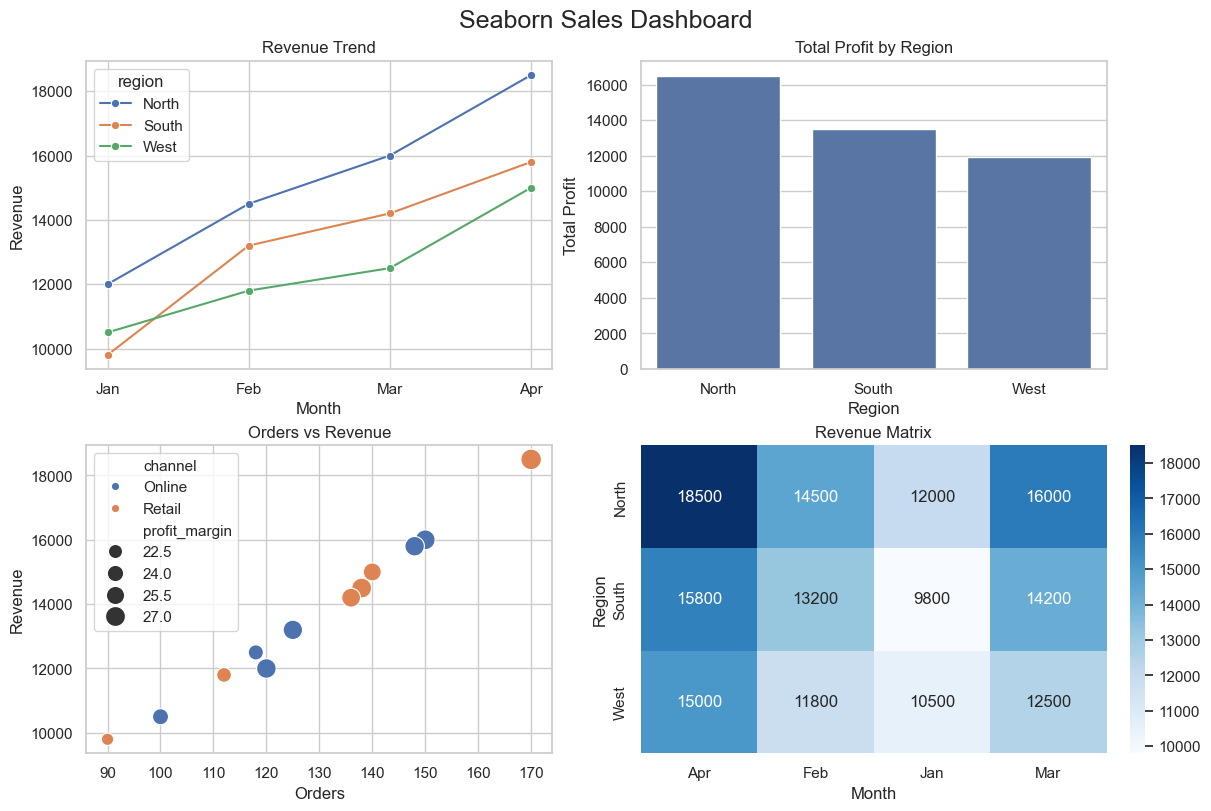

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# 1. Revenue trend by region.
sns.lineplot(data=sales, x="month", y="revenue", hue="region", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Revenue Trend")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")

# 2. Total profit by region.
sns.barplot(data=sales, x="region", y="profit", estimator="sum", errorbar=None, ax=axes[0, 1])
axes[0, 1].set_title("Total Profit by Region")
axes[0, 1].set_xlabel("Region")
axes[0, 1].set_ylabel("Total Profit")

# 3. Orders and revenue relationship.
sns.scatterplot(data=sales, x="orders", y="revenue", hue="channel", size="profit_margin", sizes=(80, 220), ax=axes[1, 0])
axes[1, 0].set_title("Orders vs Revenue")
axes[1, 0].set_xlabel("Orders")
axes[1, 0].set_ylabel("Revenue")

# 4. Month-region revenue matrix.
sns.heatmap(revenue_matrix, annot=True, fmt=".0f", cmap="Blues", ax=axes[1, 1])
axes[1, 1].set_title("Revenue Matrix")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Region")

fig.suptitle("Seaborn Sales Dashboard", fontsize=18)

plt.show()

## 26. Quick Revision Checklist

- Use tidy DataFrames with `data=`, `x=`, `y=`, and optional `hue=`.
- Use `lineplot()` for trends.
- Use `scatterplot()` and `relplot()` for relationships.
- Use `barplot()`, `countplot()`, `boxplot()`, and `violinplot()` for categorical analysis.
- Use `histplot()`, `kdeplot()`, and `ecdfplot()` for distributions.
- Use `regplot()` and `lmplot()` for regression-style visual checks.
- Use `heatmap()` for matrices and correlation tables.
- Use `pairplot()` and `jointplot()` for fast exploratory analysis.
- Use `FacetGrid`, `catplot()`, and `relplot()` for multi-panel comparisons.
- Use Matplotlib methods for final labels, titles, layout, and saving.